Pythagorean theorem

* https://en.wikipedia.org/wiki/Pythagorean_theorem
* https://www.matematica.pt/en/useful/math-formulas.php

In [4]:
# Calculate the hypotenuse (i.e. the height) of the triangle, when knowing 2 sides:
function hypotenuse(side_a::Float64, side_b::Float64)
    return sqrt( (side_a^2) + (side_b^2) ), side_a, side_b
end

hypotenuse (generic function with 1 method)

In [7]:
hypotenuse(3.0, 4.0)

(5.0, 3.0, 4.0)

In [29]:
hypotenuse3(side_a, side_b) = 
    sqrt( 
            (side_a^2) + (side_b^2) 
        ), 
    side_a, 
    side_b

hypotenuse3 (generic function with 1 method)

In [31]:
results = hypotenuse3(3, 4.0)

(5.0, 3, 4.0)

In [40]:
using Printf
@printf "Side A = %0.0f , " results[2] 
@printf "Side B = %0.2f , " results[3] 
@printf "Result = %0.5f \n" results[1] 

Side A = 3 , Side B = 4.00 , Result = 5.00000 


In [155]:
text = 
"When Xerxes 𐎧𐏁𐎹𐎠𐎼𐏁𐎠 wrote again, 'Hand over your arms.', Leonidas wrote in reply, 'μολὼν λαβέ [mo.loːn la.bé] - come and take them'."
print(text, "\n") # print the text and append a line break
println(findfirst( "Hand over your arms", text))
println(findfirst( "μολὼν λαβέ", text))
println(findfirst( "come and take them", text))
println(findfirst( "Xerxes", text))
println(findfirst( "Leonidas", text))
println("- The name of the Persian king was: ", text[begin + 5: end - 154], " 𐎧𐏁𐎹𐎠𐎼𐏁𐎠")
println("- The name of the Spartan king was: ", text[begin + 78: length(text) - 45])
println("- Xerces said: ", text[56:74])
print("- Leonidas answered: ", text[105:123])
println(", which means \"", text[146:163], "\".")

When Xerxes 𐎧𐏁𐎹𐎠𐎼𐏁𐎠 wrote again, 'Hand over your arms.', Leonidas wrote in reply, 'μολὼν λαβέ [mo.loːn la.bé] - come and take them'.
56:74
105:123
146:163
6:11
79:86
- The name of the Persian king was: Xerxes 𐎧𐏁𐎹𐎠𐎼𐏁𐎠
- The name of the Spartan king was: Leonidas 
- Xerces said: Hand over your arms
- Leonidas answered: μολὼν λαβέ, which means "come and take them".


In [181]:
# https://docs.julialang.org/en/v1/manual/integers-and-floating-point-numbers/index.html

π = parse(Float64,"3.14159265358979323846264338327950288419716939937510")
println(typeof(π), " ", π) # please note the limitation of Float64 = 3.141592653589793


function circle_area(r, π)
    return π*(r^2)
end

circle_area(2.0, π)

Float64 3.141592653589793


12.566370614359172

In [118]:
print("𐎧𐏁𐎹𐎠𐎼𐏁𐎠")

𐎧𐏁𐎹𐎠𐎼𐏁𐎠

## CUDA library

In [8]:
import Pkg
Pkg.add("CUDAapi")

  Resolving package versions...
   Updating `~/.julia/environments/v1.4/Project.toml`
 [no changes]
   Updating `~/.julia/environments/v1.4/Manifest.toml`
 [no changes]


In [9]:
using CUDAapi
has_CUDA = "false"
if has_cuda()
    @info "CUDA is on"
    has_CUDA = "true"
end

println("it is ", has_CUDA, " that I have CUDA.")

it is false that I have CUDA.


## Julia Flux

In [26]:
# import Pkg; Pkg.add("Flux")

In [27]:
using Flux

https://fluxml.ai/Flux.jl/stable/models/basics/

### Gradients

In [28]:
f(x) = 3x^2 + 2x + 1;

In [29]:
df(x) = gradient(f, x)[1]; # df/dx = 6x + 2

In [30]:
df(2)

14

In [31]:
d2f(x) = gradient(df, x)[1]; # d²f/dx² = 6

In [32]:
d2f(2)

6

In [33]:
f(x, y) = sum((x .- y).^2);

In [34]:
gradient(f, [2, 1], [2, 0])

([0, 2], [0, -2])

In [35]:
x = [2, 1];

In [36]:
y = [2, 0];

In [37]:
gs = gradient(params(x, y)) do
         f(x, y)
       end

Grads(...)

In [38]:
gs[x]

2-element Array{Int64,1}:
 0
 2

In [39]:
gs[y]

2-element Array{Int64,1}:
  0
 -2

### Simple Models 

In [41]:
W = rand(2, 5)
b = rand(2)

predict(x) = W*x .+ b

function loss(x, y)
  ŷ = predict(x)
  sum((y .- ŷ).^2)
end

x, y = rand(5), rand(2) # Dummy data
loss(x, y) # ~ 3

2.609199593593211

In [42]:
gs = gradient(() -> loss(x, y), params(W, b))

Grads(...)

In [43]:
W̄ = gs[W]

W .-= 0.1 .* W̄

loss(x, y) # ~ 2.5

1.31435044721188

### Building Layers

In [45]:
using Flux

W1 = rand(3, 5)
b1 = rand(3)
layer1(x) = W1 * x .+ b1

W2 = rand(2, 3)
b2 = rand(2)
layer2(x) = W2 * x .+ b2

model(x) = layer2(σ.(layer1(x)))

model(rand(5)) # => 2-element vector

2-element Array{Float64,1}:
 1.8750618776210581
 1.8074813814547963

In [46]:
function linear(in, out)
  W = randn(out, in)
  b = randn(out)
  x -> W * x .+ b
end

linear1 = linear(5, 3) # we can access linear1.W etc
linear2 = linear(3, 2)

model(x) = linear2(σ.(linear1(x)))

model(rand(5)) # => 2-element vector

2-element Array{Float64,1}:
 -0.6655792872565274
 -0.11638749578238317

In [47]:
struct Affine
  W
  b
end

Affine(in::Integer, out::Integer) =
  Affine(randn(out, in), randn(out))

# Overload call, so the object can be used as a function
(m::Affine)(x) = m.W * x .+ m.b

a = Affine(10, 5)

a(rand(10)) # => 5-element vector

5-element Array{Float64,1}:
 -3.4963697275724126
 -1.0709496903678688
  2.570993268768314
  1.0274635261898968
 -2.6225558976785734

### Stacking It Up

In [48]:
layer1 = Dense(10, 5, σ)
# ...
model(x) = layer3(layer2(layer1(x)))

ErrorException: invalid redefinition of constant layer1

In [49]:
using Flux

layers = [Dense(10, 5, σ), Dense(5, 2), softmax]

model(x) = foldl((x, m) -> m(x), layers, init = x)

model(rand(10)) # => 2-element vector

2-element Array{Float32,1}:
 0.7847207
 0.21527933

In [50]:
model2 = Chain(
  Dense(10, 5, σ),
  Dense(5, 2),
  softmax)

model2(rand(10)) # => 2-element vector

2-element Array{Float32,1}:
 0.29834837
 0.7016517

In [51]:
m = Dense(5, 2) ∘ Dense(10, 5, σ)

m(rand(10))

2-element Array{Float32,1}:
 0.15926346
 0.17256233

In [52]:
m = Chain(x -> x^2, x -> x+1)

m(5) # => 26

26

### Layer helpers

In [53]:
Flux.@functor Affine

In [54]:
outdims(c::Chain, isize)

UndefVarError: UndefVarError: c not defined

In [55]:
m = Chain(Conv((3, 3), 3 => 16), Conv((3, 3), 16 => 32))
outdims(m, (10, 10)) == (6, 6)

UndefVarError: UndefVarError: outdims not defined

In [56]:
m = Dense(10, 5)
outdims(m, (5, 2)) == (5,)
outdims(m, (10,)) == (5,)

UndefVarError: UndefVarError: outdims not defined

## FluxML/Metalhead.jl

In [83]:
## Uncomment the lines below if you have not run it previously
# import Pkg; Pkg.add("Metalhead")
# import Pkg; Pkg.add("QuartzImageIO")

In [84]:
using Metalhead
using Metalhead: classify
vgg = VGG19()

VGG19()

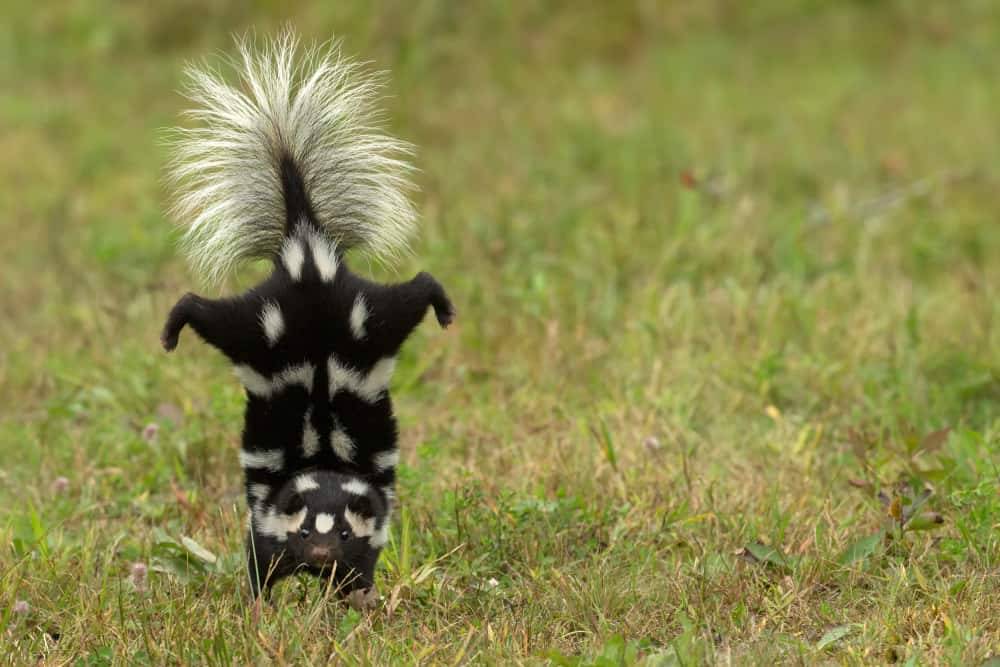

In [91]:
## local file in this lab's folder
image = load("skunk001.jpeg")

In [86]:
classify(vgg, image)

"skunk, polecat, wood pussy"

# Knet

In [5]:
## Uncomment the lines below if you have not run it previously
# import Pkg; Pkg.add("Knet")
#import Pkg; Pkg.add("CodecZlib")

In [6]:
using Knet

# Define convolutional layer:
struct Conv; w; b; f; end
(c::Conv)(x) = c.f.(pool(conv4(c.w, x) .+ c.b))
Conv(w1,w2,cx,cy,f=relu) = Conv(param(w1,w2,cx,cy), param0(1,1,cy,1), f)

Conv

In [7]:
# Define convolutional layer:
struct Conv; w; b; f; end
(c::Conv)(x) = c.f.(pool(conv4(c.w, x) .+ c.b))
Conv(w1,w2,cx,cy,f=relu) = Conv(param(w1,w2,cx,cy), param0(1,1,cy,1), f)

# Define dense layer:
struct Dense; w; b; f; end
(d::Dense)(x) = d.f.(d.w * mat(x) .+ d.b)
Dense(i::Int,o::Int,f=relu) = Dense(param(o,i), param0(o), f)

# Define a chain of layers and a loss function:
struct Chain; layers; end
(c::Chain)(x) = (for l in c.layers; x = l(x); end; x)
(c::Chain)(x,y) = nll(c(x),y)

# Load MNIST data:
include(Knet.dir("data","mnist.jl"))
dtrn, dtst = mnistdata()

# Define, train and test LeNet (about 30 secs on a gpu to reach 99% accuracy)
LeNet = Chain((Conv(5,5,1,20), Conv(5,5,20,50), Dense(800,500), Dense(500,10,identity)))
adam!(LeNet, repeat(dtrn,10))
accuracy(LeNet, dtst)

┌ Info: Loading MNIST...
└ @ Main /Users/uki/.julia/packages/Knet/7mHKz/data/mnist.jl:33
┌ Warning: repeat(d::Data,n) is deprecated, use IterTools.ncycle instead.
└ @ Knet /Users/uki/.julia/packages/Knet/7mHKz/src/data.jl:92


0.9902